In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pymeasure.instruments.agilent import AgilentB1500

In [2]:
# explicitly define r/w terminations; set sufficiently large timeout in milliseconds or None.
b1500 = AgilentB1500("GPIB2::17::INSTR", read_termination='\r\n', write_termination='\r\n', timeout=600000)

c:\Users\UNL_microscope\Heesoo_test\pythonTest\.venv\Lib\site-packages\pymeasure\instruments\generic_types.py:110: FutureWarning: It is not known whether this device support SCPI commands or not. Please inform the pymeasure maintainers if you know the answer.
  warn("It is not known whether this device support SCPI commands or not. Please inform "


In [3]:
# FYI
print(dir(b1500))

['BaseChannelCreator', 'ChannelCreator', 'MultiChannelCreator', 'SCPI', '_CommonBase__reserved_prefix', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_create_channels', '_data_formatting', '_data_formatting_FMT1', '_data_formatting_FMT11', '_data_formatting_FMT21', '_data_formatting_generic', '_fget_params_list', '_fset_params_list', '_setup_special_names', '_smu_names', '_smu_references', '_special_names', 'abort', 'adapter', 'adc_auto_zero', 'adc_averaging', 'adc_setup', 'add_child', 'ask', 'auto_calibration', 'binary_values', 'check_errors', 'check_get_errors', 'check_idle', 'check_set_errors', 'clear', 'c

In [4]:
# pyVISA test
import pyvisa

rm = pyvisa.ResourceManager()
inst = rm.open_resource('GPIB2::17::INSTR')
inst.timeout = 20000

print(inst.query("*IDN?"))

Agilent Technologies,B1500A,0,A.06.02.2023.0401



In [5]:
print(inst.query("UNT?"))

B1517A,0;B1517A,0;B1517A,0;B1530A,0;0,0;0,0;0,0;0,0;0,0;0,0



혹은 이런 식으로 query를 보낼 수 있다.

In [6]:
b1500.ask('UNT?')

'B1517A,0;B1517A,0;B1517A,0;B1530A,0;0,0;0,0;0,0;0,0;0,0;0,0'

총 10개의 module 중 처음 3개만 사용, B1530A는 WGFMU인데 이것도 사용하는지? <br>
→ 현재 PyMeasure 라이브러리 (`.venv\Lib\site-packages\pymeasure\instruments\agilent\agilentB1500.py`, Line 109) 에는 없음

아래 코드는 `NotImplementedError: Module B1530A is not implemented yet!` 라는 Error를 반환한다.

---

```python
# query SMU config from instrument and initialize all SMU instances
b1500.initialize_all_smus()
```

---

- 왜냐면 라이브러리에 B1530A가 없기 때문...
- 그래서 일단 Library에 `'B1530A': 'WGFMU'`를 추가한 코드를 돌리는 아주 비효율적인 방법을 써보면...

In [28]:
# code from lib to check `NotImplementedError`

modules = b1500.ask('UNT?')
modules = modules.split(';')
module_names = {
    'B1525A': 'SPGU',
    'B1517A': 'HRSMU',
    'B1511A': 'MPSMU',
    'B1511B': 'MPSMU',
    'B1510A': 'HPSMU',
    'B1514A': 'MCSMU',
    'B1520A': 'MFCMU',
    'B1530A': 'WGFMU'       # custom-modified (2025.02.17.)
}
out = {}
for i, module in enumerate(modules):
    module = module.split(',')
    if not module[0] == '0':
        try:
            out[i + 1] = module_names[module[0]]
            # i+1: channels start at 1 not at 0
        except Exception:
            raise NotImplementedError(
                f'Module {module[0]} is not implemented yet!')
print(out)

{1: 'HRSMU', 2: 'HRSMU', 3: 'HRSMU', 4: 'WGFMU'}


---

Line 154, `initialize_all_smus()` function

```python
def initialize_all_smus(self):
    """ Initialize all SMUs by querying available modules and creating
    a SMU class instance for each.
    SMUs are accessible via attributes ``.smu1`` etc.
    """
    modules = self.query_modules()
    i = 1
    for channel, smu_type in modules.items():
        if 'SMU' in smu_type:
            setattr(self, 'smu' + str(i),
                    self.initialize_smu(
                        channel, smu_type, 'SMU' + str(i)))
            i += 1
```

---

In [ ]:
modules = out
i = 1
for channel, smu_type in modules.items():
    if 'SMU' in smu_type:
        setattr(b1500, 'smu' + str(i),
                b1500.initialize_smu(
                    channel, smu_type, 'SMU' + str(i)))
        i += 1

### Output Format

In [9]:
# set data output format (required!)
b1500.data_format(21, mode=1) #call after SMUs are initialized to get names for the channels

이 코드는
1. `b1500.write("FMT 21, 1")`
2. `b1500.check_errors()`
3. `b1500._data_format = b1500._data_formatting("FMT21", b1500._smu_names)`


위 3개의 코드를 실행시키는 것과 같다. 이때 `b1500._data_formatting()` 함수의 역할은 FMT1, 11, 21에 맞는 `b1500._data_formatting_FMT00`을 ...

---

```python
class _data_formatting_FMT21(_data_formatting_generic):
    """ Data formatting for FMT21 format
    """

    def __init__(self, smu_names={}):
        super().__init__(smu_names, "FMT21")

    def format_single(self, element):
        """ Format single measurement value

        :param element: Single measurement value read from the instrument
        :type element: str
        :return: Status (three digits), channel, data name, value
        :rtype: (str, str, str, float)
        """
        status = element[0:3]  # three digits
        channel = element[3]
        data_name = element[4]
        data_name = self.data_names[data_name]
        if data_name in self.data_names_int:
            value = int(float(element[5:]))
        else:
            value = float(element[5:])
        channel = self.format_channel_check_status(status, channel)

        return (status, channel, data_name, value)
```

---

In [10]:
# choose measurement mode
b1500.meas_mode('STAIRCASE_SWEEP', *b1500.smu_references) #order in smu_references determines order of measurement

In [11]:
# settings for individual SMUs
for smu in b1500.smu_references:
    smu.enable() #enable SMU
    smu.adc_type = 'HRADC' #set ADC to high-resoultion ADC
    smu.meas_range_current = '1 uA'
    smu.meas_op_mode = 'COMPLIANCE_SIDE'

In [13]:
b1500.smu_names

{1: 'SMU1', 2: 'SMU2', 3: 'SMU3'}

In [14]:
# General Instrument Settings
b1500.adc_setup('HRADC','AUTO', 6)

In [15]:
# Sweep Settings
b1500.sweep_timing(0, 5, step_delay=0.1)  # hold, delay
b1500.sweep_auto_abort(False, post='STOP')  # disable auto abort, set post measurement output condition to stop value of sweep

In [16]:
# Sweep Source
nop = 11
b1500.smu1.staircase_sweep_source('VOLTAGE','LINEAR_DOUBLE','Auto Ranging',0,1,nop,0.001) #type, mode, range, start, stop, steps, compliance

In [17]:
# Synchronous Sweep Source
b1500.smu2.synchronous_sweep_source('VOLTAGE','Auto Ranging',0,1,0.001) #type, range, start, stop, comp

In [18]:
# Constant Output (could also be done using synchronous sweep source with start=stop, but then the output is not ramped up)
b1500.smu3.ramp_source('VOLTAGE','Auto Ranging',-1,stepsize=0.1,pause=20e-3) #output starts immediately! (compared to sweeps)

In [19]:
#Start Measurement
b1500.check_errors()
b1500.clear_buffer()
b1500.clear_timer()
b1500.send_trigger()

In [20]:
b1500.check_idle()

In [21]:
# read measurement data all at once
b1500.check_idle() #wait until measurement is finished
data = b1500.read_data(2*nop) #Factor 2 because of double sweep

c:\Users\UNL_microscope\Heesoo_test\pythonTest\.venv\Lib\site-packages\pymeasure\instruments\agilent\agilentB1500.py:865: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(self._data_format.format_single)
c:\Users\UNL_microscope\Heesoo_test\pythonTest\.venv\Lib\site-packages\pymeasure\instruments\agilent\agilentB1500.py:866: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heads = data.iloc[[0]].applymap(lambda x: ' '.join(x[1:3]))
c:\Users\UNL_microscope\Heesoo_test\pythonTest\.venv\Lib\site-packages\pymeasure\instruments\agilent\agilentB1500.py:870: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: x[3])


In [22]:
data

,SMU1 Current Measurement (A),SMU2 Current Measurement (A),SMU3 Current Measurement (A),SMU1 Voltage Output (V)
0,0.000000e+00,0.000000e+00,0.000000e+00,0.0
1,0.000000e+00,-2.000000e-11,0.000000e+00,0.1
2,0.000000e+00,0.000000e+00,0.000000e+00,0.2
3,0.000000e+00,0.000000e+00,0.000000e+00,0.3
4,2.000000e-11,0.000000e+00,0.000000e+00,0.4
5,0.000000e+00,-2.000000e-11,0.000000e+00,0.5
6,0.000000e+00,-2.000000e-11,0.000000e+00,0.6
7,2.000000e-11,0.000000e+00,0.000000e+00,0.7
8,0.000000e+00,0.000000e+00,0.000000e+00,0.8
9,0.000000e+00,0.000000e+00,0.000000e+00,0.9


In [ ]:
data.to_csv('measurement.csv')

In [23]:
#sweep constant sources back to 0V
b1500.smu3.ramp_source('VOLTAGE','Auto Ranging',0,stepsize=0.1,pause=20e-3)

In [24]:
# Check if instrument is idle
b1500.ask("*OPC?")

'1'

In [25]:
b1500.check_idle()

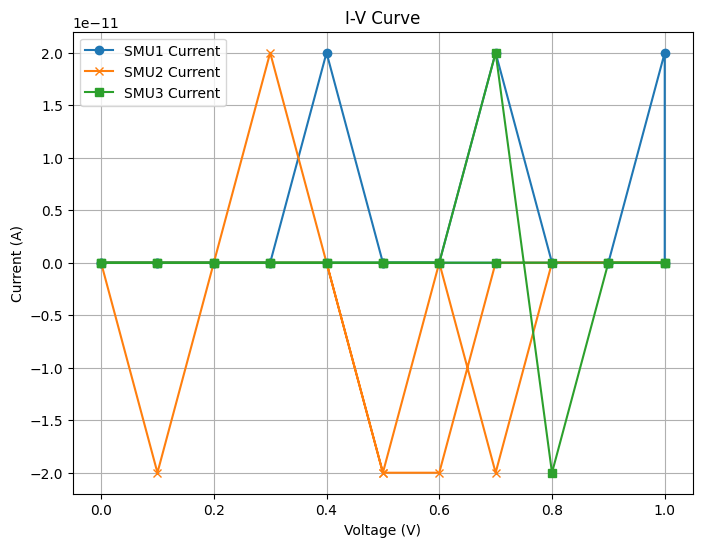

In [27]:
df = pd.DataFrame(data)

# plot
plt.figure(figsize=(8, 6))

plt.plot(df['SMU1 Voltage Output (V)'], df['SMU1 Current Measurement (A)'], label="SMU1 Current", marker='o')
plt.plot(df['SMU1 Voltage Output (V)'], df['SMU2 Current Measurement (A)'], label="SMU2 Current", marker='x')
plt.plot(df['SMU1 Voltage Output (V)'], df['SMU3 Current Measurement (A)'], label="SMU3 Current", marker='s')

# label
plt.title('I-V Curve')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.legend()

# display
plt.grid(True)
plt.show()